### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import os
import missingno
import joblib
from datasist.structdata import detect_outliers
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder, PolynomialFeatures, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn_features.transformers import DataFrameSelector
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,confusion_matrix,r2_score,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

### `Read Dataset`

In [2]:
File_Path = os.path.join(os.getcwd(),'winequality-red.csv')
df = pd.read_csv(File_Path)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### `Data Analysis`

In [3]:
df.columns = df.columns.str.replace(' ', '_')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
df.shape

(1599, 12)

In [7]:
df.quality.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [8]:
## to check if there null values
df.apply(lambda x: len(x.isnull()))

fixed_acidity           1599
volatile_acidity        1599
citric_acid             1599
residual_sugar          1599
chlorides               1599
free_sulfur_dioxide     1599
total_sulfur_dioxide    1599
density                 1599
pH                      1599
sulphates               1599
alcohol                 1599
quality                 1599
dtype: int64

In [9]:
#check cols that have nulls
cols = pd.DataFrame(df.isna().sum() > 0, columns=['null_or_not'])
cols_with_nulls = cols[cols['null_or_not']].index.to_list()
cols_with_nulls

[]

In [10]:
df[cols_with_nulls]

""
0
1
2
3
4
...
1594
1595
1596
1597


In [11]:
df.isna().sum(axis=0).sort_values(ascending=False)

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

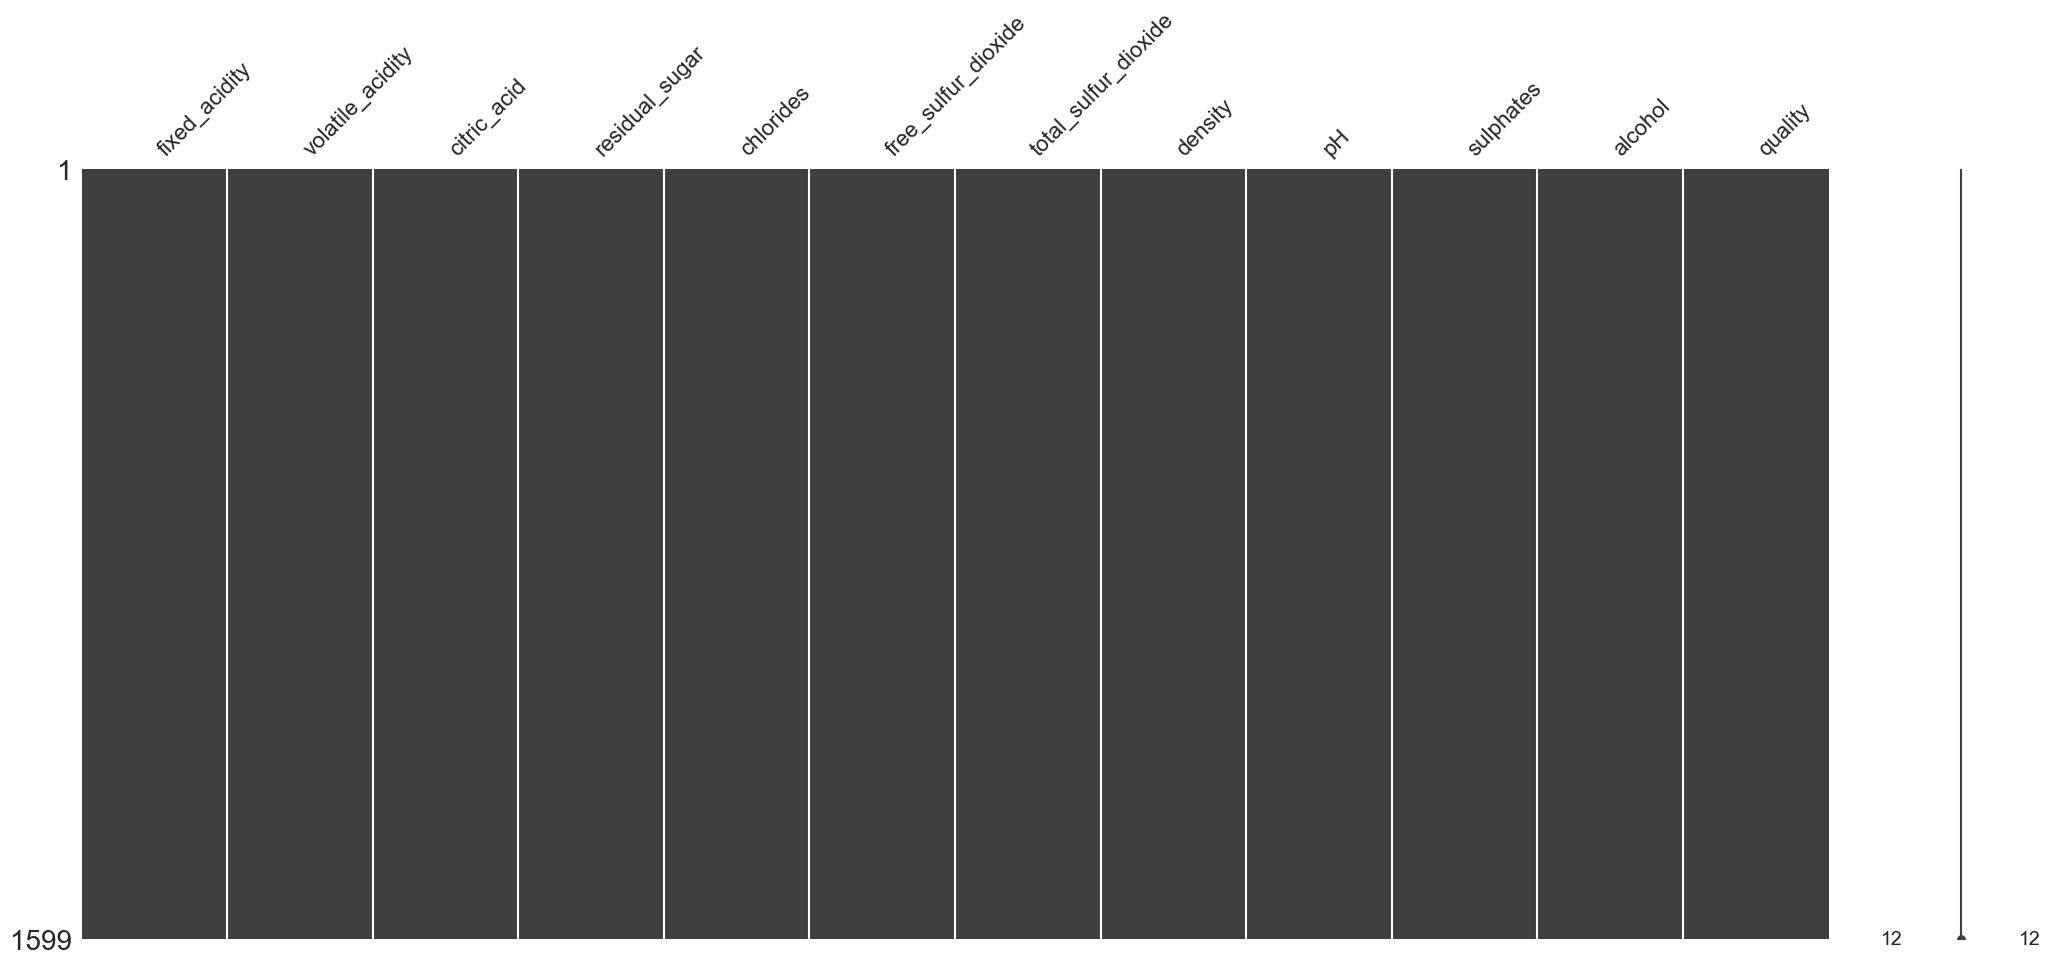

In [12]:
missingno.matrix(df)
plt.show()

In [13]:
# Check duplicates
df.duplicated().sum(axis=0)

240

In [14]:
# drop Duplicates
df.drop_duplicates(inplace=True)

In [15]:
# To check if there unique values in Dataset
df.apply(lambda x: len(x.unique()))

fixed_acidity            96
volatile_acidity        143
citric_acid              80
residual_sugar           91
chlorides               153
free_sulfur_dioxide      60
total_sulfur_dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64

### `EDA`

In [16]:
num_cols = df.select_dtypes(include='number').columns.to_list()
num_cols

['fixed_acidity',
 'volatile_acidity',
 'citric_acid',
 'residual_sugar',
 'chlorides',
 'free_sulfur_dioxide',
 'total_sulfur_dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [17]:
categ_cols = df.select_dtypes(include='object').columns.tolist()
categ_cols

[]

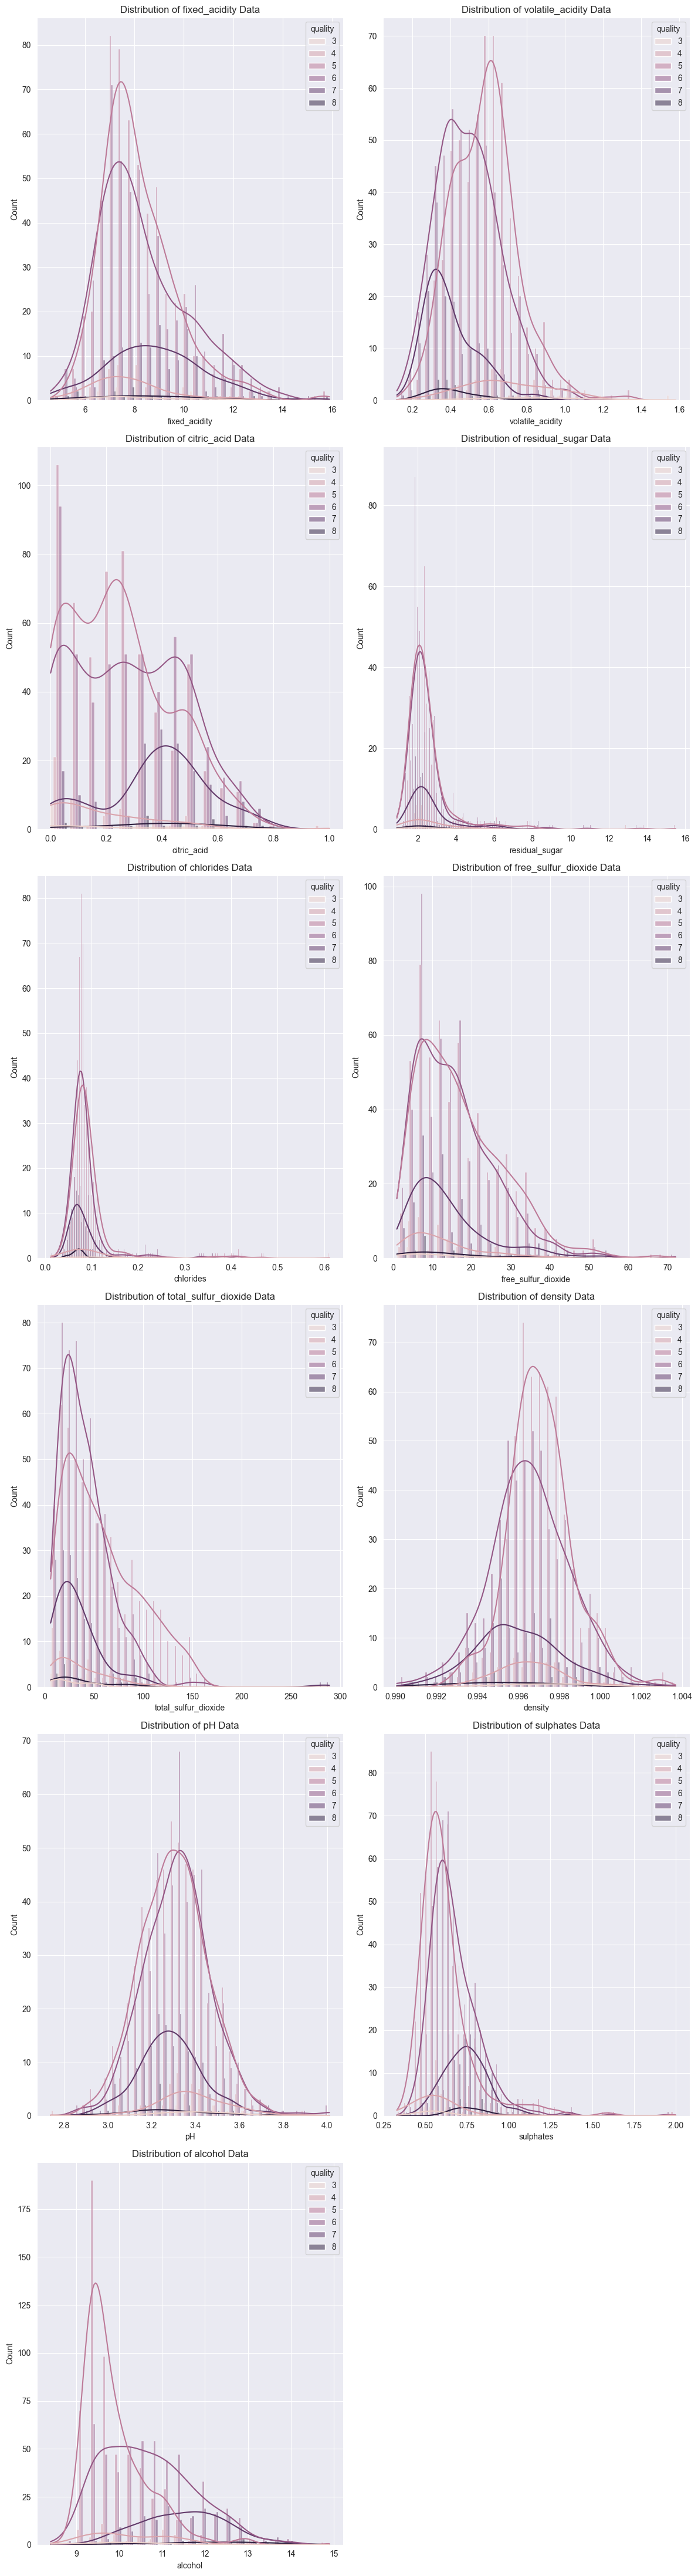

In [18]:
cols = df.columns[:-1].tolist()
plt.figure(figsize = (12, 44))
for i, col in enumerate(cols, 1):
    plt.subplot(6, 2, i)
    sns.histplot(x = df[col], hue = df["quality"], kde = True, multiple = "dodge")
    plt.title(f"Distribution of {col} Data")
    plt.tight_layout()
    plt.plot()

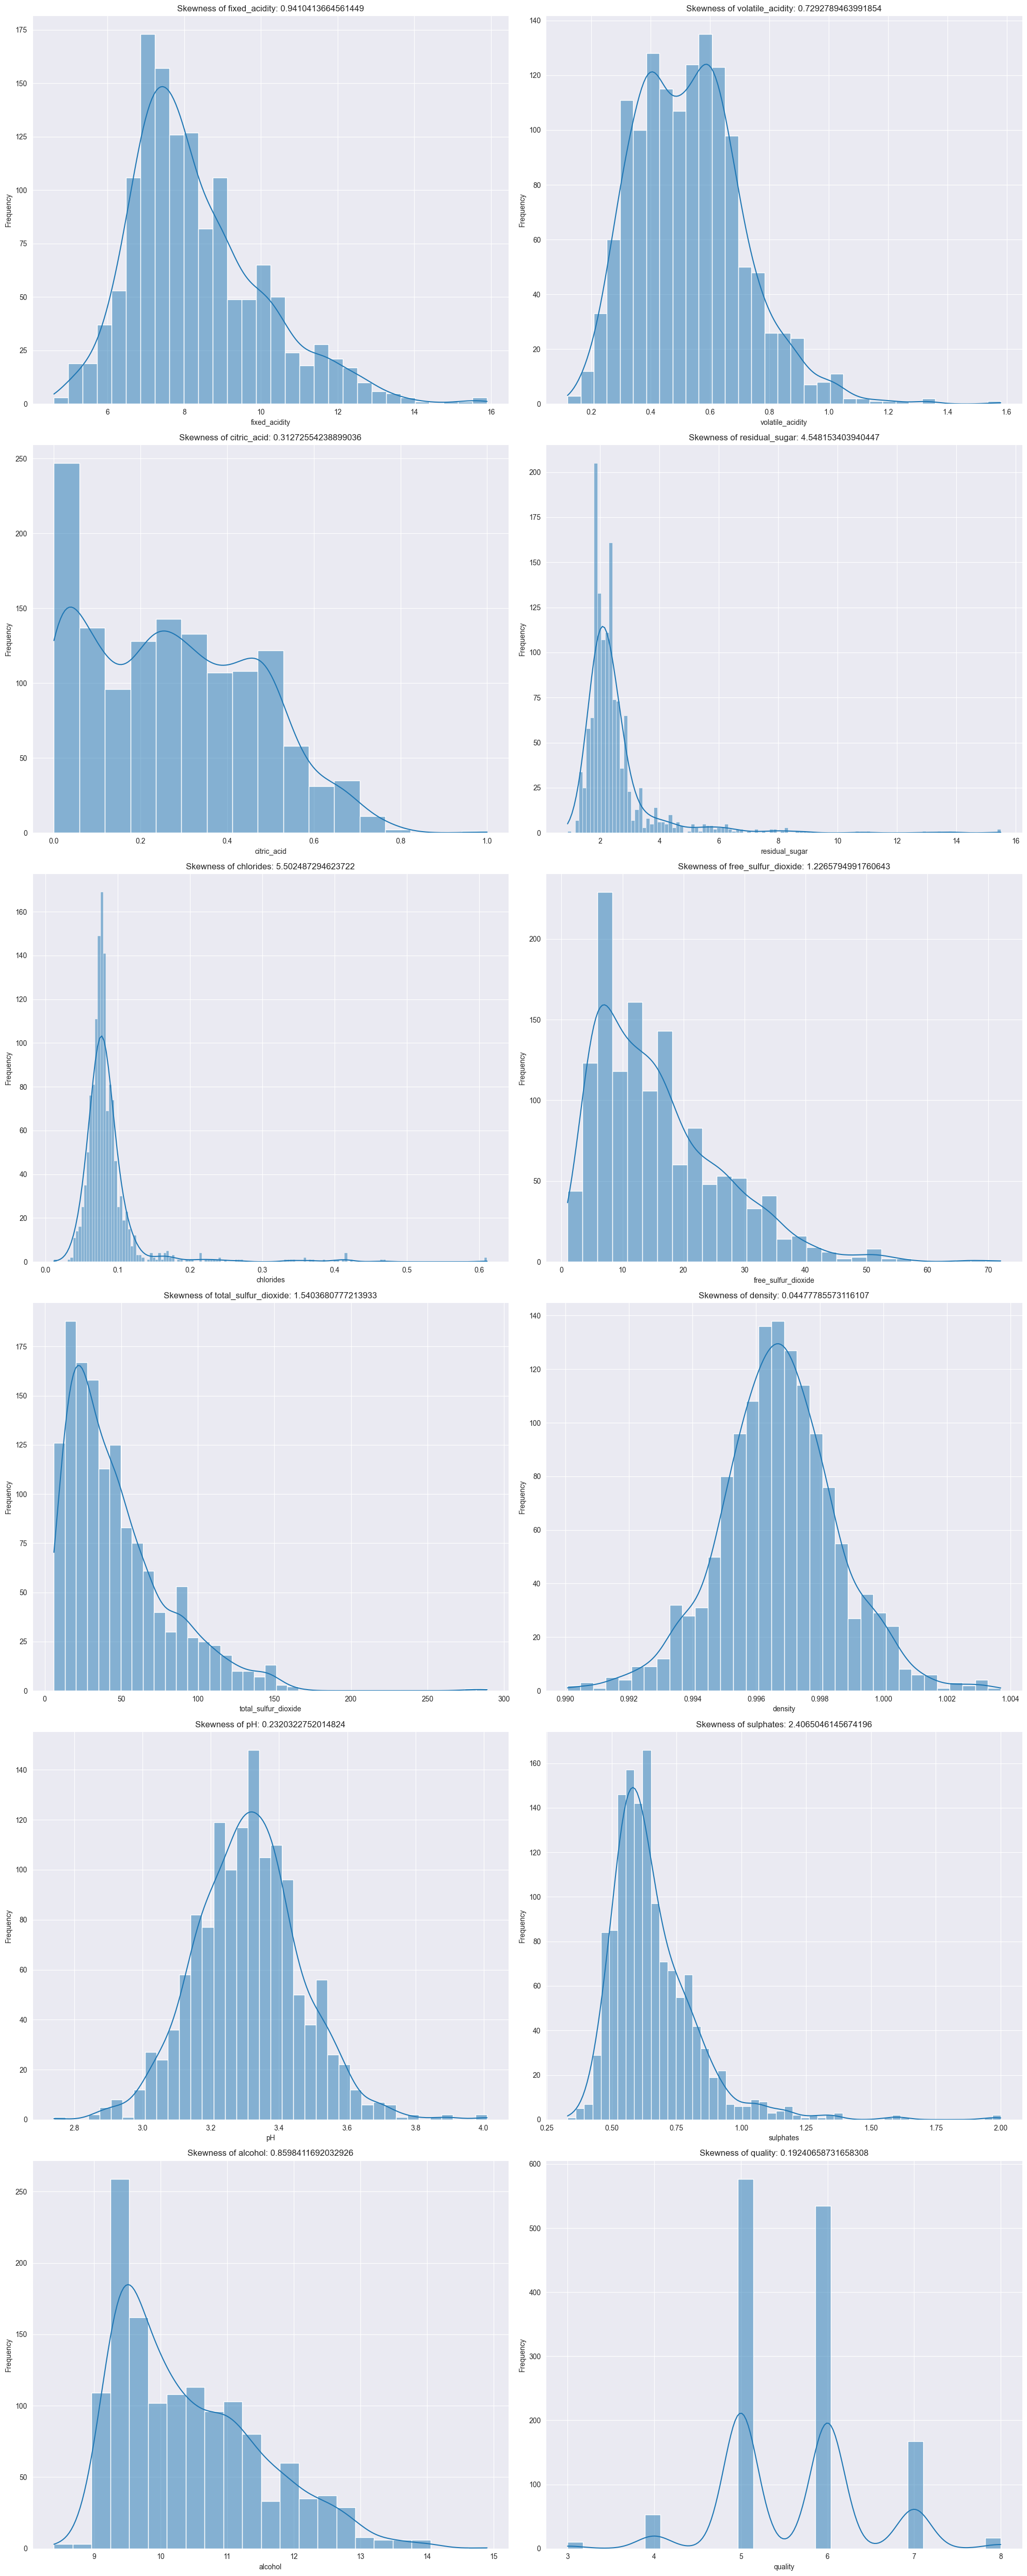

In [19]:
# Plot skewness for each numeric column
plt.figure(figsize=(20, 50))
for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Skewness of {col}: {df[col].skew()}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

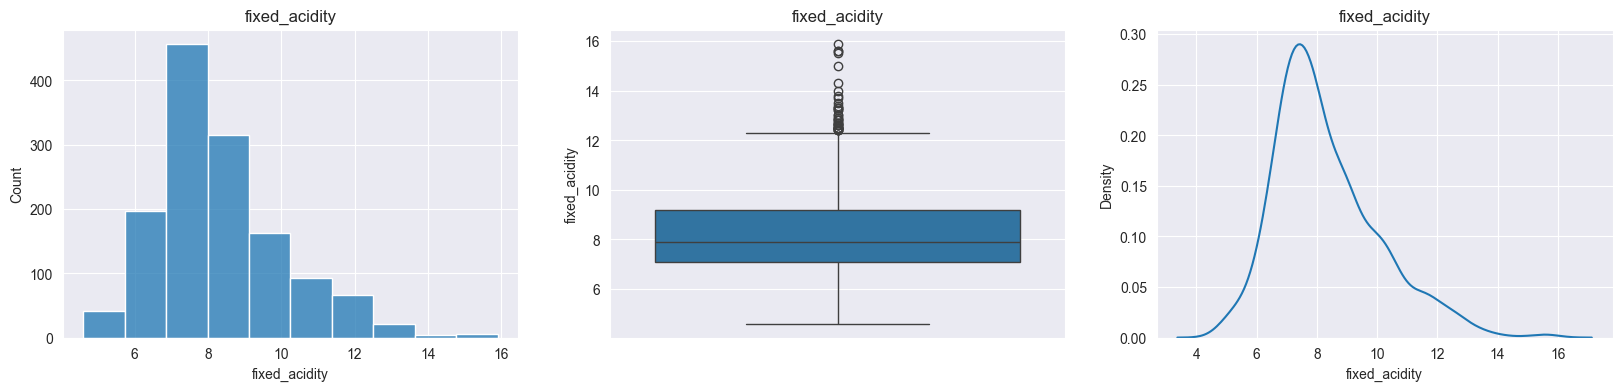

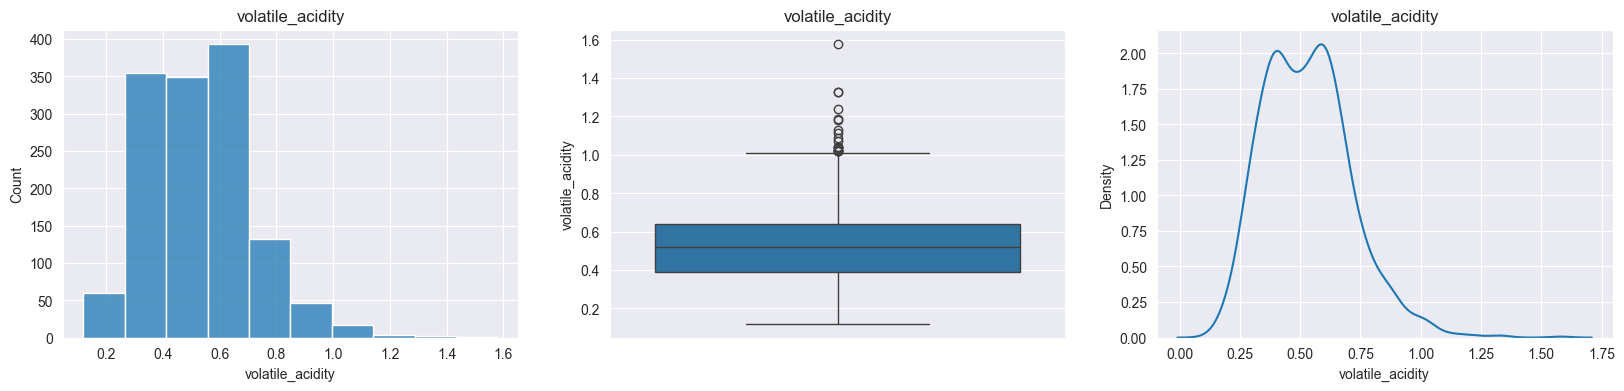

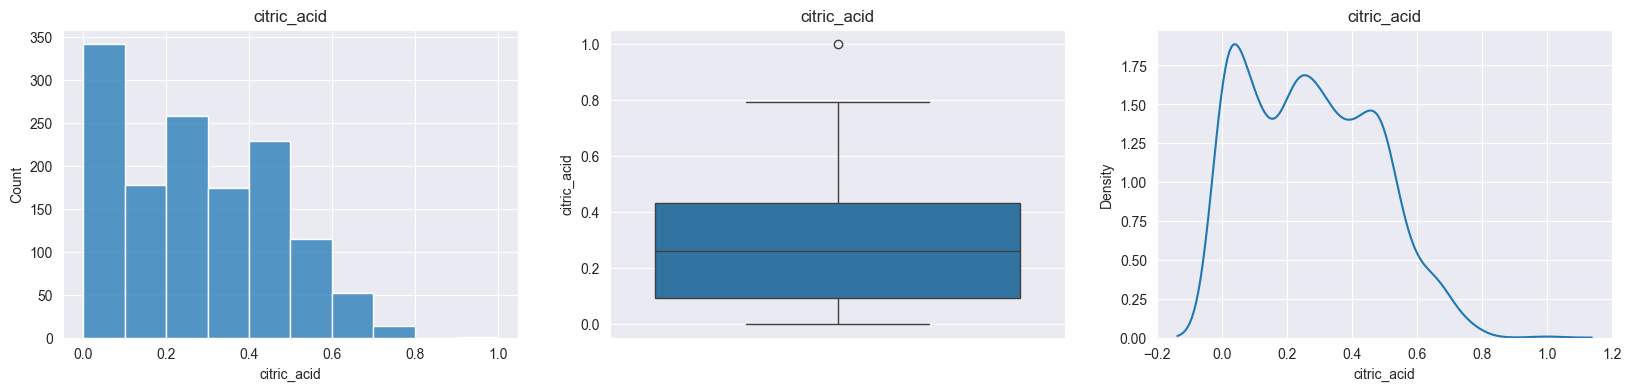

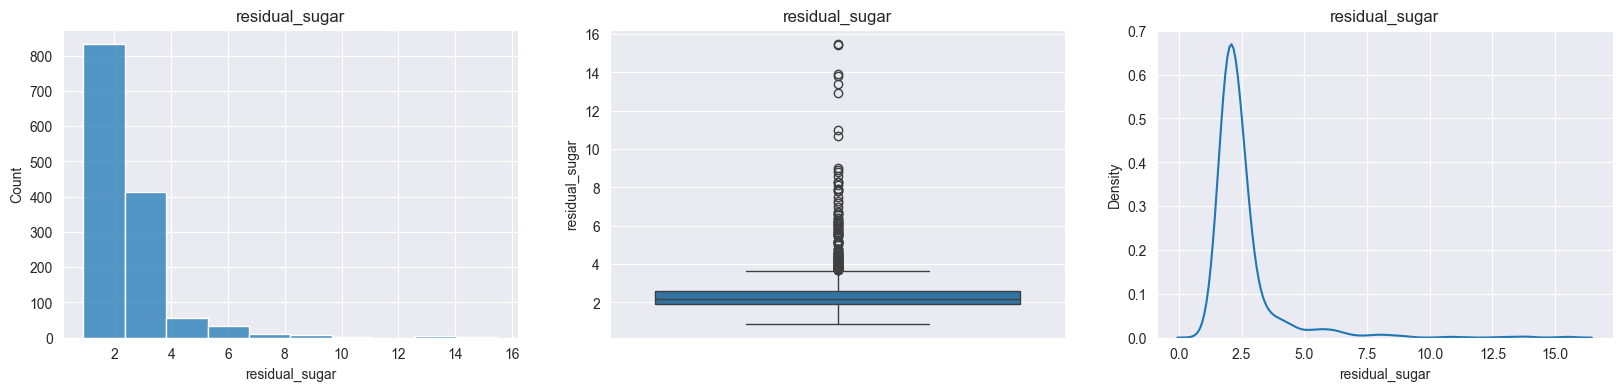

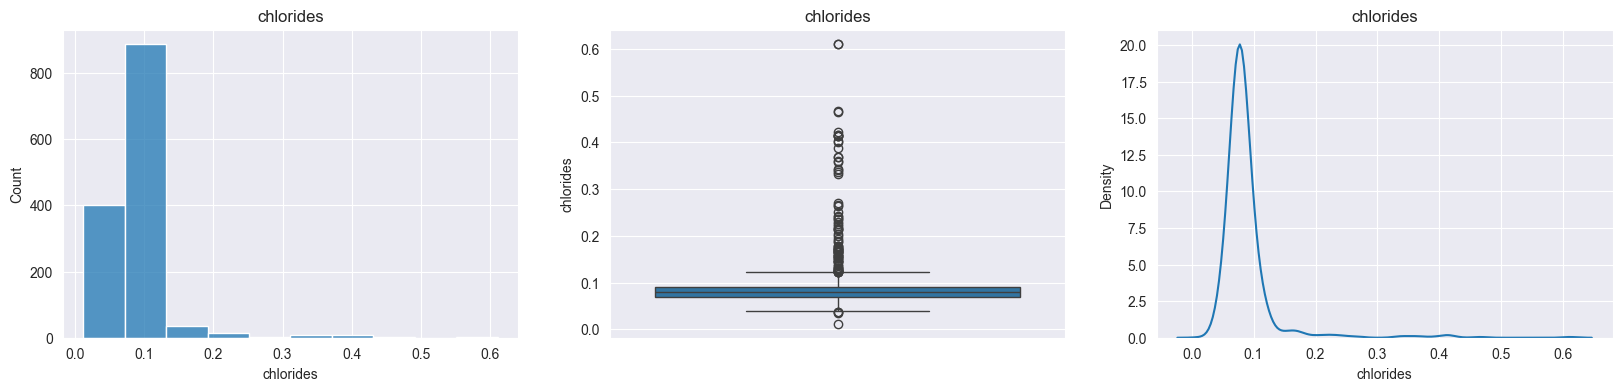

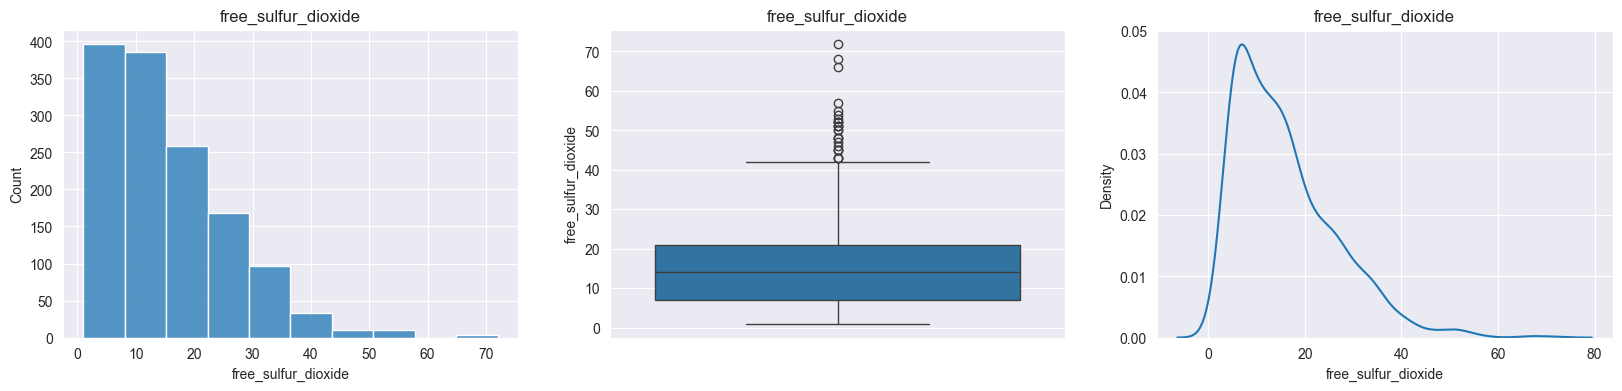

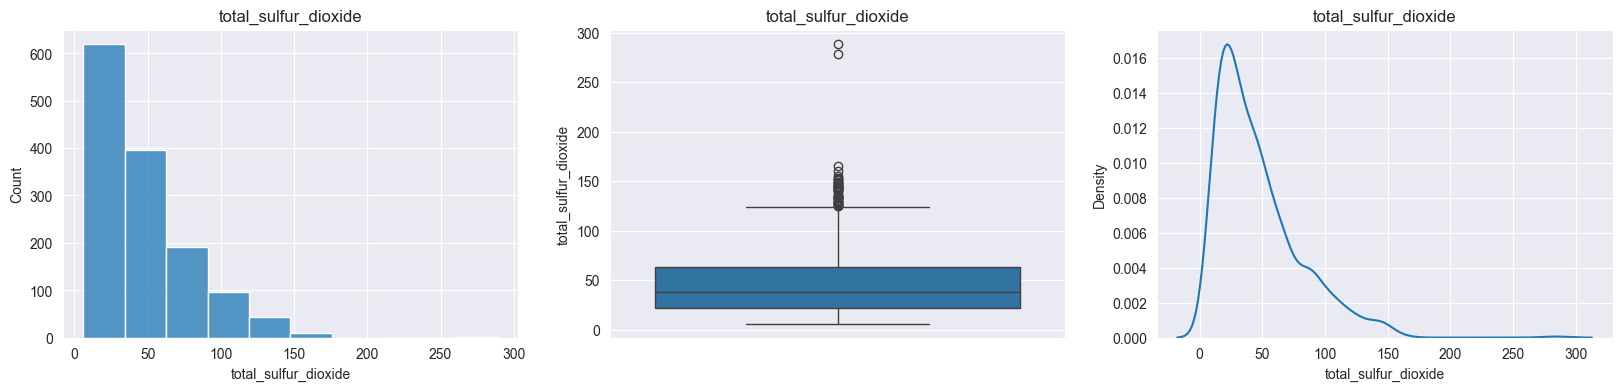

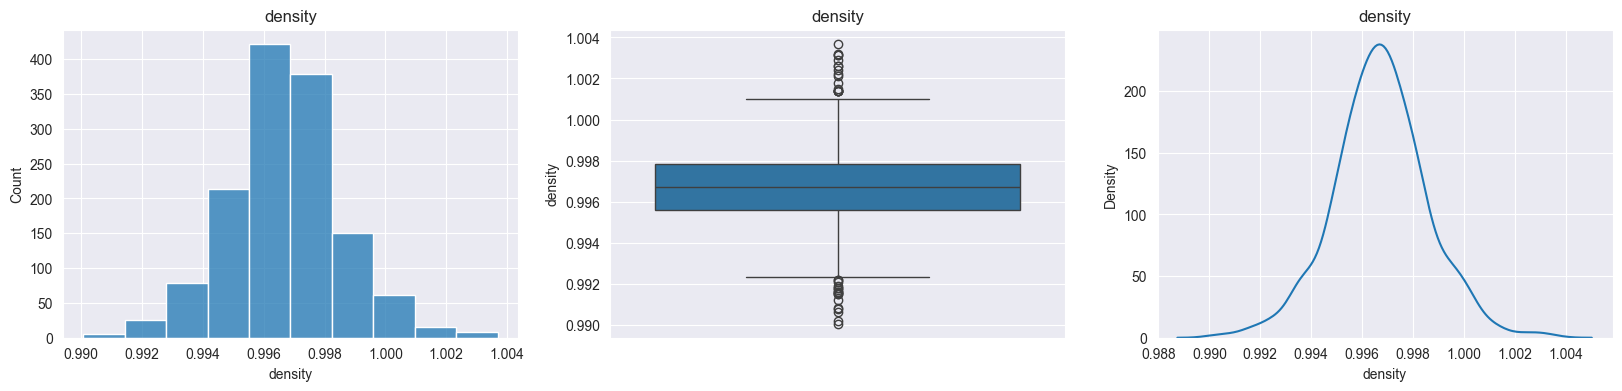

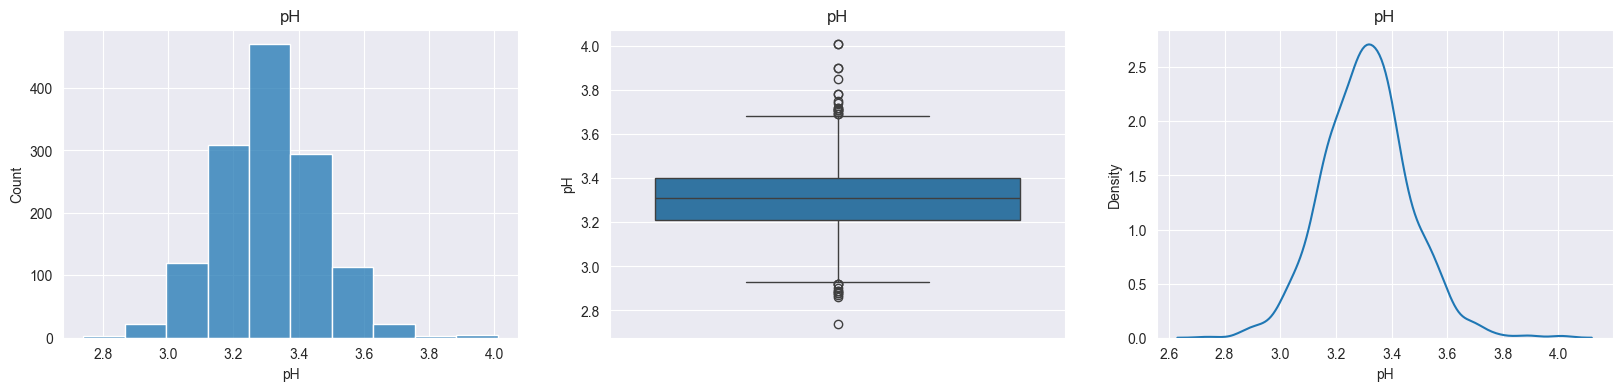

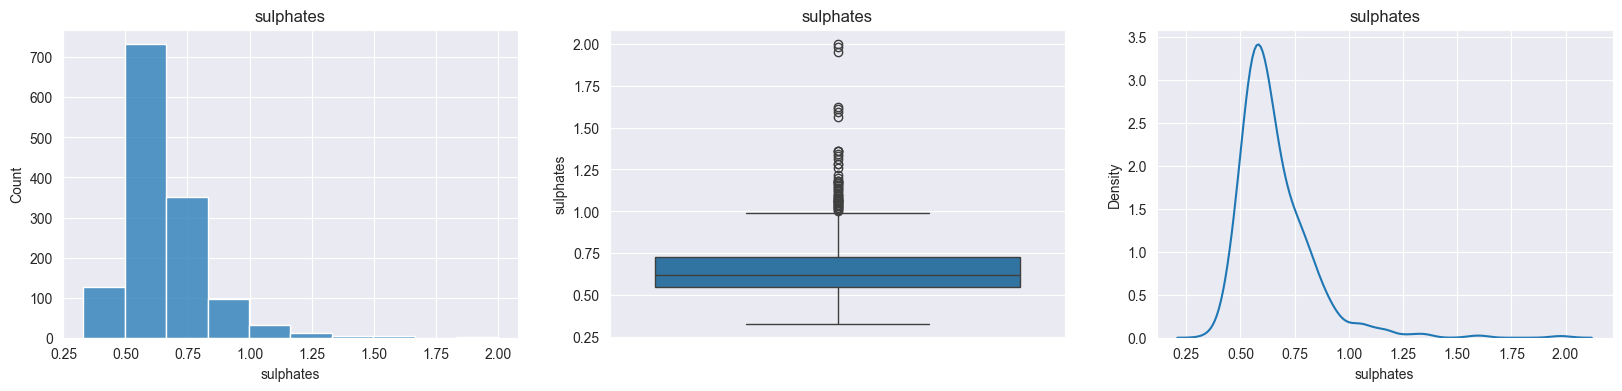

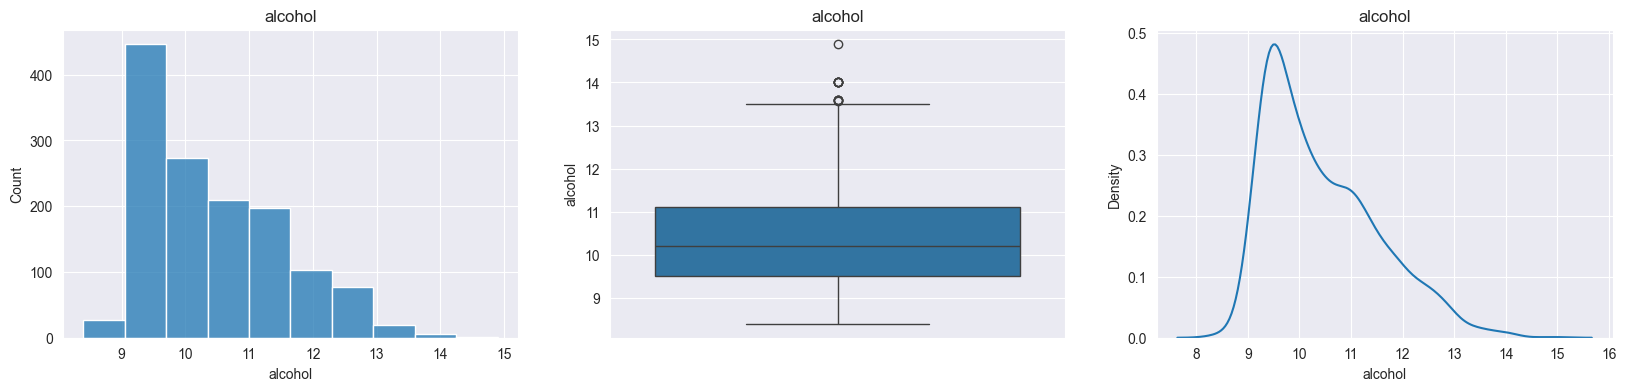

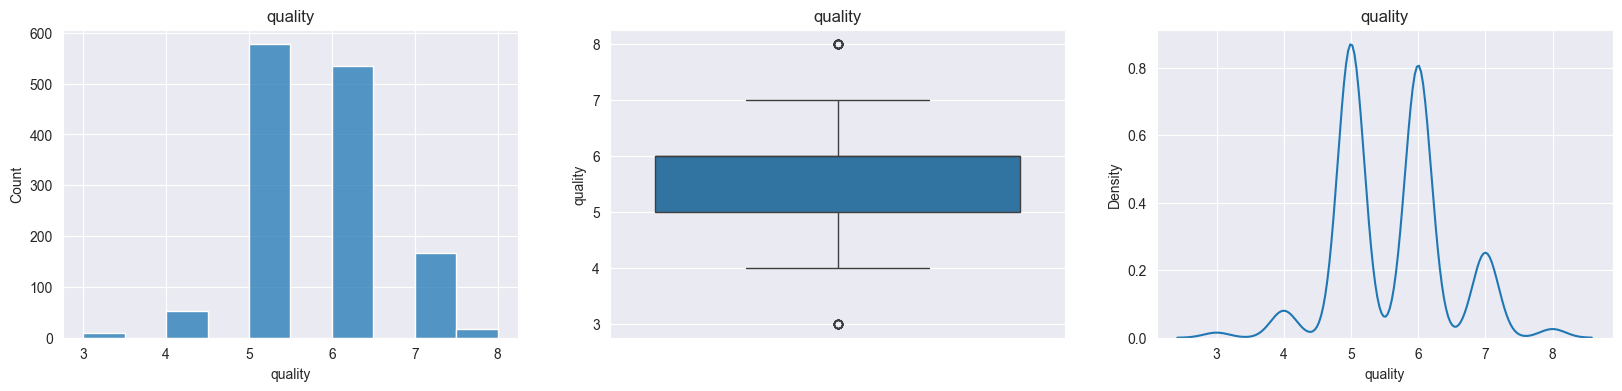

In [20]:
def graph(df):
    num_cols
    for i in num_cols:
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 4))
        
        sns.histplot(x=df[i], bins=10, ax=axes[0])
        axes[0].set_title(i)
        
        sns.boxplot(y=df[i], orient='Horizontal', ax=axes[1])  # Use horizontal orientation
        axes[1].set_title(i)
        
        sns.kdeplot(x=df[i], ax=axes[2], warn_singular=False)
        axes[2].set_title(i)
        
        plt.show()

# Call the function with your DataFrame
graph(df)

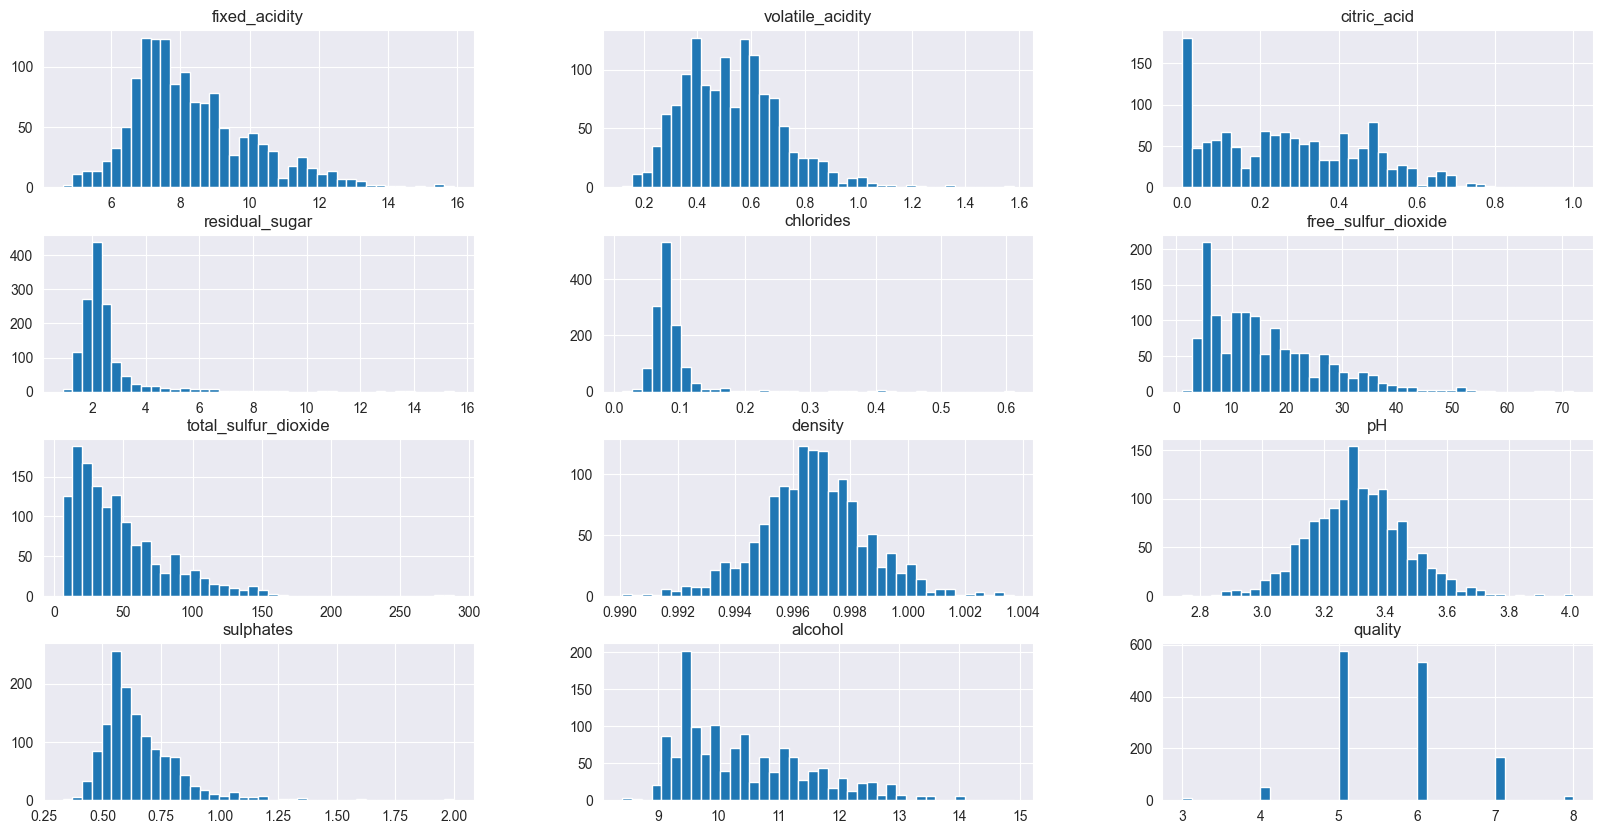

In [21]:
## Check Distribution before handling outliers
df.hist(bins=40, figsize=(20,10))
plt.show()

In [22]:
## Get the Numerical cols firstly
num_cols1 = df.select_dtypes(include='number').columns.tolist()[:-1]
num_cols1

for col in num_cols1:
    each_idx = detect_outliers(data=df, n=0, features=[col])
    each_median = df[col].median()

    df.loc[each_idx, col] = each_median

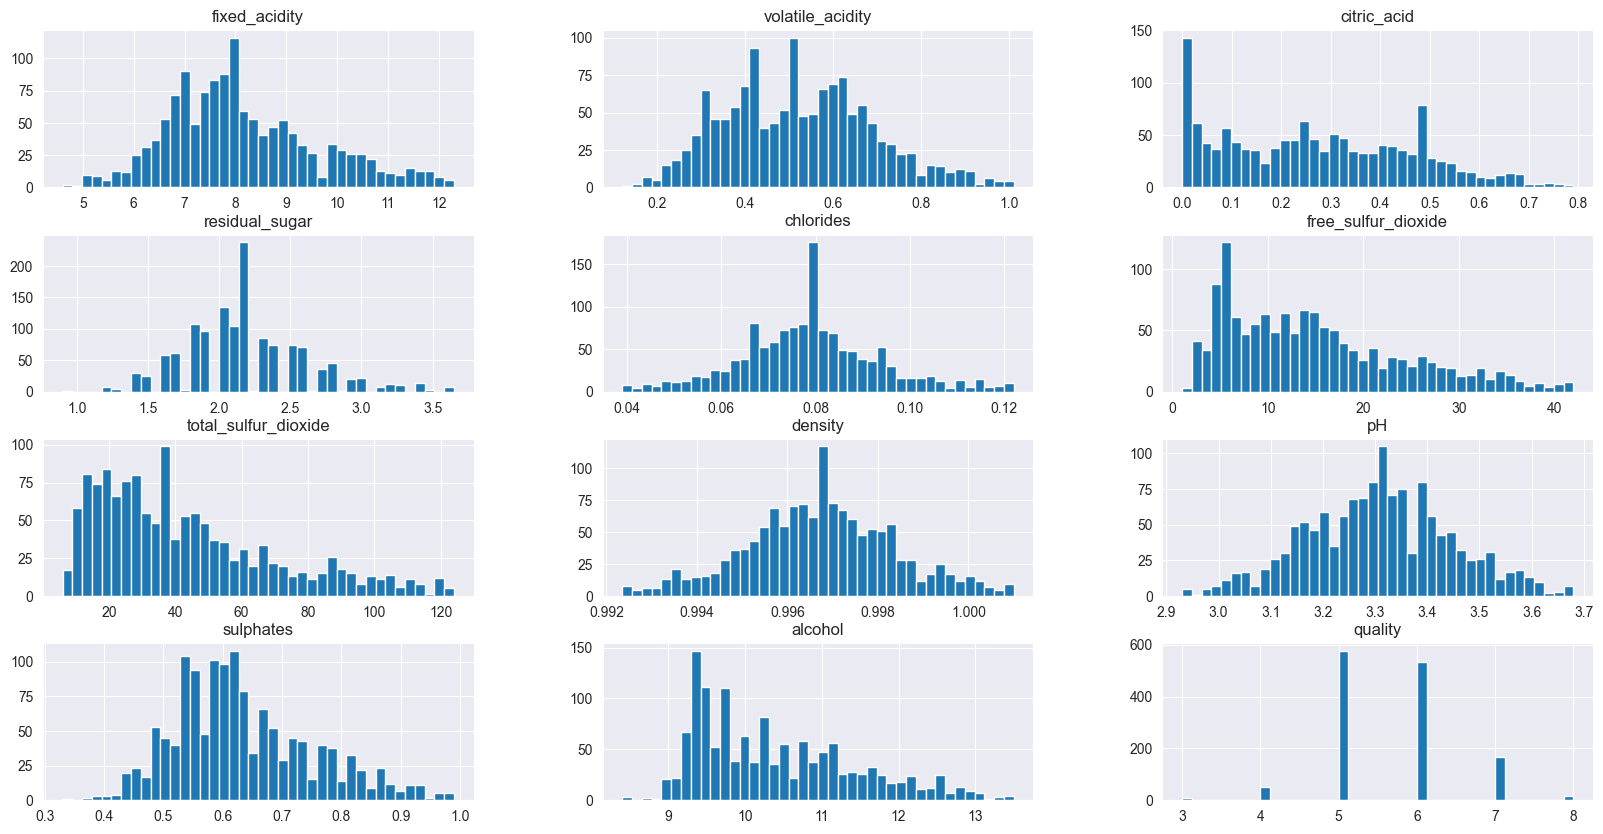

In [23]:
## Check Distribution after handling outliers
df.hist(bins=40, figsize=(20,10))
plt.show()

<Axes: >

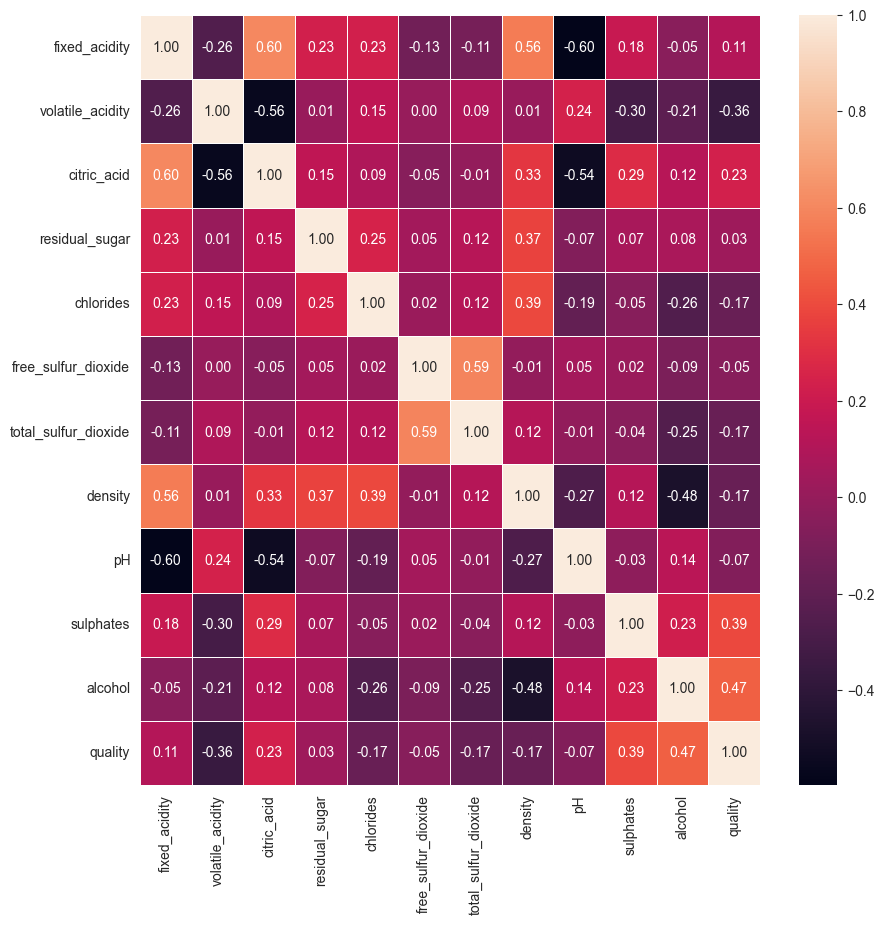

In [24]:
# Check correlation
plt.figure(figsize=(10,10))
sns.heatmap(df[num_cols].corr(), annot=True, linewidth=0.5, fmt='0.2f')

### `Split the Dataset`

In [25]:
X =df.drop(columns=['quality'], axis=1)
y = df['quality']

# Feature Selection
# Feature Selection is a techinque of finding out the features that contribute the most to our model i.e. the best predictors.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, shuffle=True, random_state=45,stratify=y)

### `Data Preprocessing`

In [26]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
# Handling the imbalance data
over = SMOTE()
X_train_resampled,y_train_resampled = over.fit_resample(X_train_scaled,y_train)
y_train_resampled.value_counts(), y_train.value_counts()

(quality
 6    461
 5    461
 4    461
 7    461
 3    461
 8    461
 Name: count, dtype: int64,
 quality
 5    461
 6    428
 7    134
 4     42
 8     14
 3      8
 Name: count, dtype: int64)

In [28]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit label encoder and transform y_train
y_train_encoded = label_encoder.fit_transform(y_train)

# Fit label encoder (only transform) on y_test
y_test_encoded = label_encoder.transform(y_test)

### `Build Models`

### `1.Logistic Regression`

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.78      0.69       116
           6       0.54      0.60      0.57       107
           7       0.71      0.15      0.25        33
           8       0.00      0.00      0.00         3

    accuracy                           0.58       272
   macro avg       0.31      0.25      0.25       272
weighted avg       0.56      0.58      0.55       272



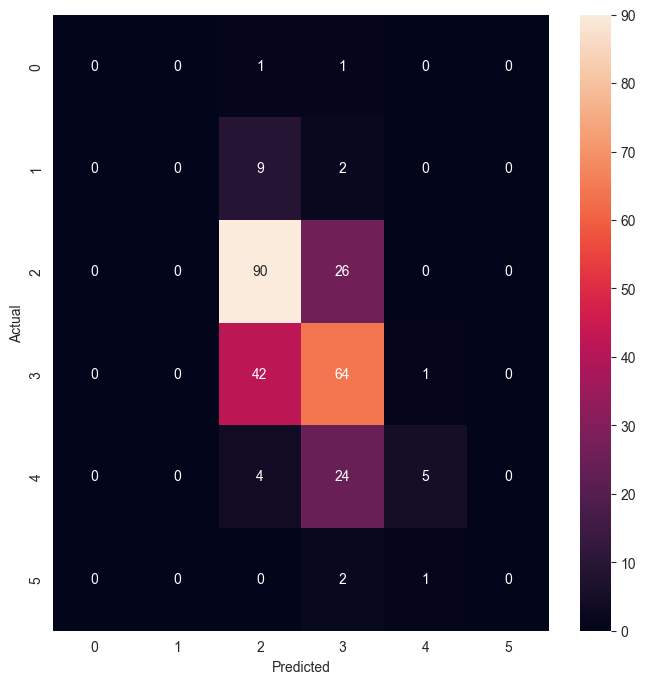

In [29]:
param_grid_log = {
'C':[0.001,0.01,0.1,1,10,100],
'max_iter':[1000,1500,2000]}
log=RandomizedSearchCV(LogisticRegression(solver='lbfgs'),param_grid_log,cv=5)
log.fit(X_train_scaled,y_train)
y_pred_log=log.predict(X_test_scaled)
confusion_log=confusion_matrix(y_test,log.predict(X_test_scaled))
plt.figure(figsize=(8,8))
sns.heatmap(confusion_log,annot=True,fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
print(classification_report(y_test, y_pred_log, zero_division=0))

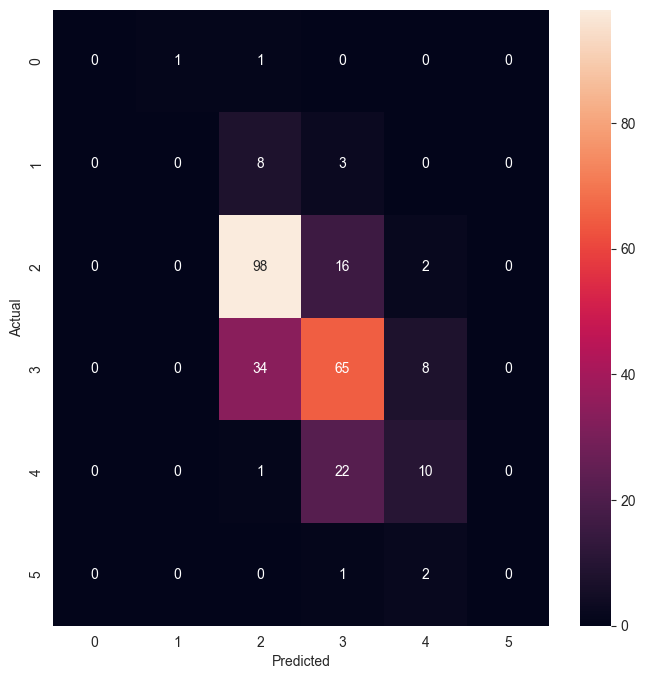

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.69      0.84      0.76       116
           6       0.61      0.61      0.61       107
           7       0.45      0.30      0.36        33
           8       0.00      0.00      0.00         3

    accuracy                           0.64       272
   macro avg       0.29      0.29      0.29       272
weighted avg       0.59      0.64      0.61       272


Best Parameter: {'n_estimators': 325}


Best Estimator: RandomForestClassifier(n_estimators=325, random_state=42)



In [30]:
param_grid = {
'n_estimators': np.arange(50,401,25)
}

# Initialize and fit RandomizedSearchCV
rcv=RandomizedSearchCV(RandomForestClassifier(random_state=42),param_grid,cv=5)
rcv.fit(X_train_scaled,y_train)

# Predict on test data
y_pred_rcv=rcv.predict(X_test_scaled)

# Generate confusion matrix
confusion_rcv=confusion_matrix(y_test,rcv.predict(X_test_scaled))

# Plot confusion matrix
plt.figure(figsize=(8,8))
sns.heatmap(confusion_rcv,annot=True, fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report with zero_division parameter to handle zero divisions
print(classification_report(y_test, y_pred_rcv, zero_division=0))
print(f'\nBest Parameter: {rcv.best_params_}\n')
print(f'\nBest Estimator: {rcv.best_estimator_}\n')


In [31]:
## Getting the Features Importance (they are normalized in RF, sum=1)
feat_import_forest = {}   ## to append in it
for name, score in zip(num_cols, rcv.best_estimator_.feature_importances_):
    feat_import_forest[name] = score
    
## Features are keys, Importance is the value
keys_forest = feat_import_forest.keys()
values_forest = feat_import_forest.values()

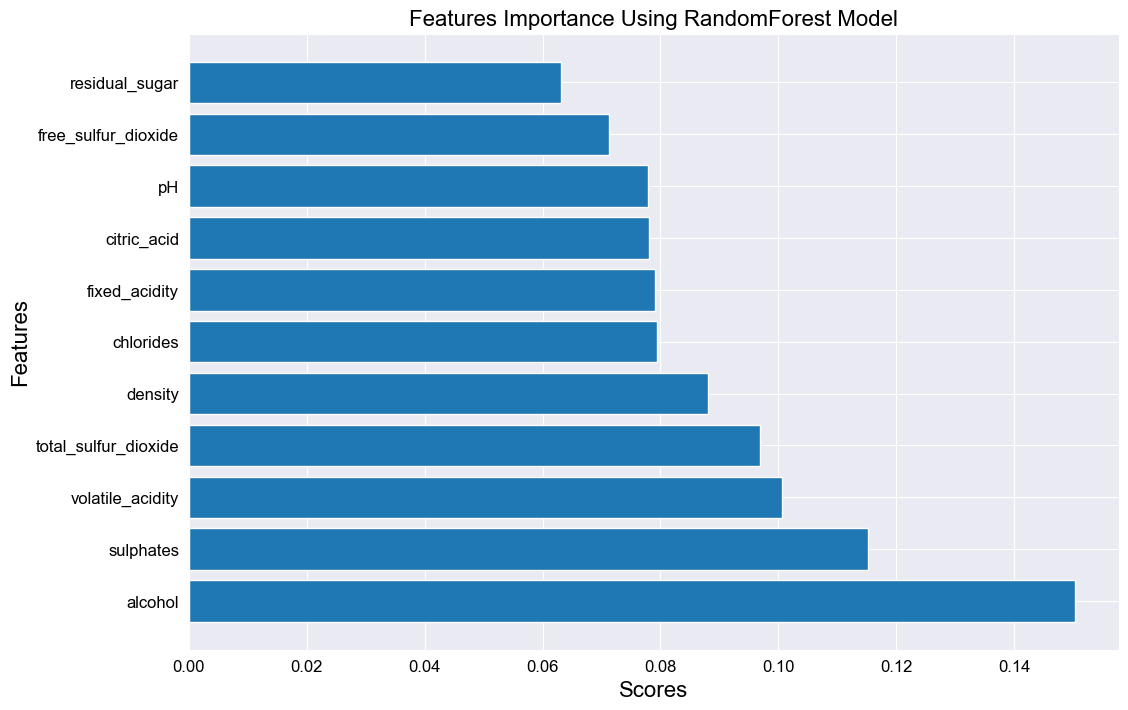

In [32]:
## to DF and then plotting
df_feat_import_forest = pd.DataFrame({'Features': keys_forest, 'Scores': values_forest})
df_feat_import_forest = df_feat_import_forest.sort_values(by='Scores', ascending=False)

## plotting
plt.figure(figsize=(12, 8))
plt.barh(y=df_feat_import_forest['Features'], width=df_feat_import_forest['Scores'])
plt.title('Features Importance Using RandomForest Model', fontsize=16, c='k')
plt.xlabel('Scores', fontsize=16, c='k')
plt.ylabel('Features', fontsize=16, c='k')
plt.xticks(c='k', fontsize=12)
plt.yticks(c='k', fontsize=12)
plt.grid('on')
plt.show()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00        11
           2       0.67      0.74      0.70       116
           3       0.56      0.58      0.57       107
           4       0.42      0.39      0.41        33
           5       0.00      0.00      0.00         3

    accuracy                           0.59       272
   macro avg       0.27      0.29      0.28       272
weighted avg       0.55      0.59      0.57       272


Best Parameter: {'n_estimators': 50}


Best Estimator: XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constrai

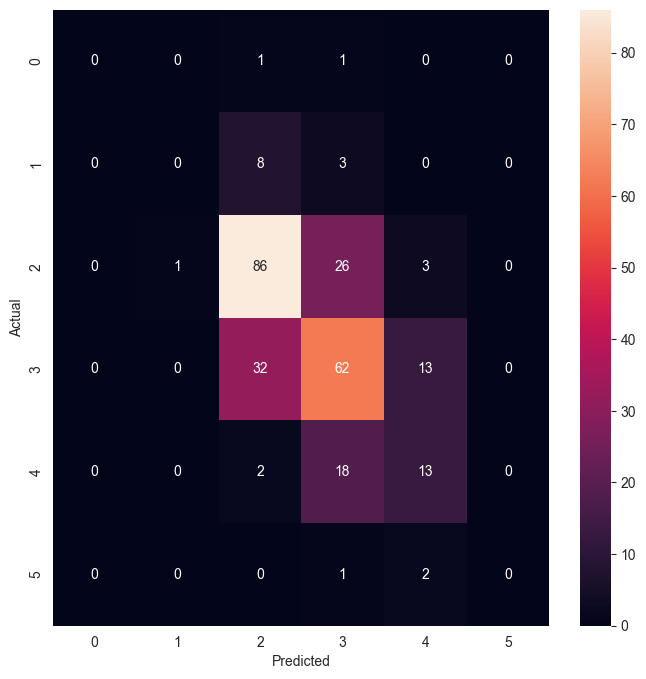

In [33]:
# Create XGBoost classifier instance
xgb_classifier = XGBClassifier(random_state=42)

# Create RandomizedSearchCV instance
rcv_xgb = RandomizedSearchCV(estimator=xgb_classifier, param_distributions=param_grid, n_iter=10, scoring='accuracy', cv=5, verbose=1, random_state=42)

# Fit the RandomizedSearchCV
rcv_xgb.fit(X_train_scaled, y_train_encoded)

# Make predictions on the validation set
y_pred_xgb = rcv_xgb.predict(X_test_scaled)

# Generate confusion matrix
confusion_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

# Plot confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(confusion_xgb, annot=True, fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Print classification report
print(classification_report(y_test_encoded, y_pred_xgb, zero_division=0))

# Print best parameters and best estimator
print(f'\nBest Parameter: {rcv_xgb.best_params_}\n')
print(f'\nBest Estimator: {rcv_xgb.best_estimator_}\n')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00        11
           2       0.67      0.74      0.70       116
           3       0.56      0.58      0.57       107
           4       0.42      0.39      0.41        33
           5       0.00      0.00      0.00         3

    accuracy                           0.59       272
   macro avg       0.27      0.29      0.28       272
weighted avg       0.55      0.59      0.57       272


Best Parameter: {'n_estimators': 50}


Best Estimator: XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constrai

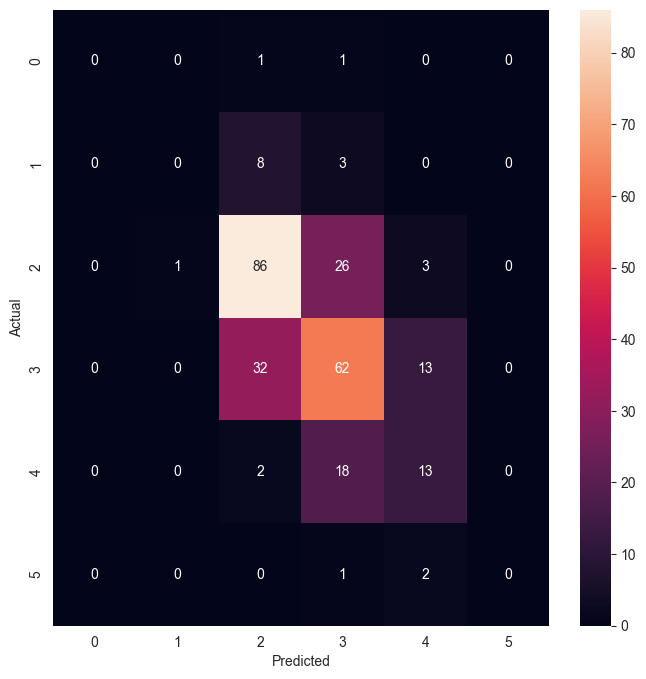

In [34]:
param_grid_xgb = {
'n_estimators': np.arange(100,500,50),
'max_depth': np.arange(4,20,2),
'max_samples':[0.7,0.8,0.9,1.0],
'learning_rate': [0.05, 0.1, 0.2]
}

# Create XGBClassifier instance
xgb_classifier = XGBClassifier(random_state=42)

# Create RandomizedSearchCV instance
rcv=RandomizedSearchCV(estimator=xgb_classifier, param_distributions=param_grid_xgb, n_iter=10, scoring='accuracy', cv=5, verbose=1, random_state=42)

# Fit the RandomizedSearchCV
rcv_xgb.fit(X_train_scaled, y_train_encoded)

# Make predictions on the validation set
y_pred_xgb = rcv_xgb.predict(X_test_scaled)

# Generate confusion matrix
confusion_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

# Plot confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(confusion_xgb, annot=True, fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Print classification report
print(classification_report(y_test_encoded, y_pred_xgb, zero_division=0))

# Print best parameters and best estimator
print(f'\nBest Parameter: {rcv_xgb.best_params_}\n')
print(f'\nBest Estimator: {rcv_xgb.best_estimator_}\n')

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.58      0.74      0.65       116
           6       0.54      0.61      0.57       107
           7       0.75      0.09      0.16        33
           8       0.00      0.00      0.00         3

    accuracy                           0.57       272
   macro avg       0.31      0.24      0.23       272
weighted avg       0.55      0.57      0.52       272


Best Parameter: {'gamma': 1, 'C': 1}


Best Estimator: SVC(C=1, gamma=1)



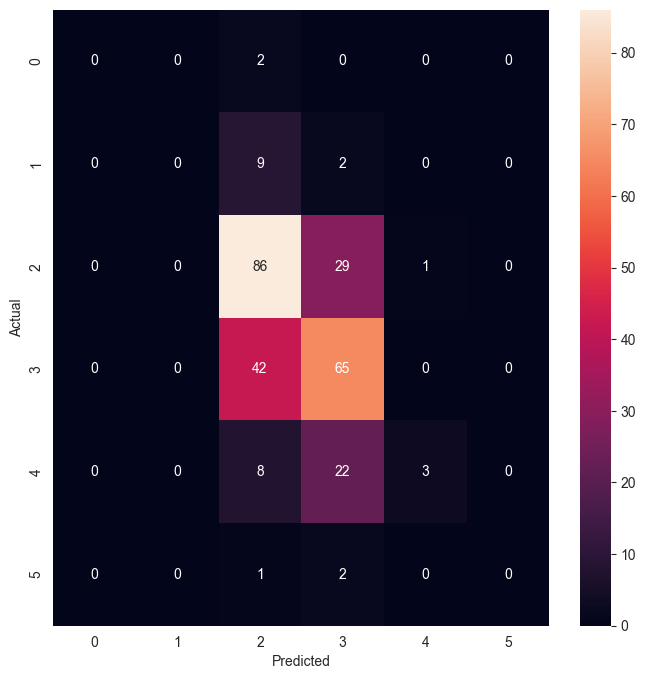

In [35]:

param_grid_svc={'C':[0.001,0.01,0.1,1,10,100], 'gamma':[1,10,100]}

# Create RandomizedSearchCV instance
rcv_svc = RandomizedSearchCV(SVC(), param_distributions=param_grid_svc, cv=5)

# Fit the RandomizedSearchCV
rcv_svc.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svc = rcv_svc.predict(X_test_scaled)

# Evaluate the model
confusion_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(8, 8))
sns.heatmap(confusion_svc, annot=True, fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")

print(classification_report(y_test, y_pred_svc, zero_division=0))
print(f'\nBest Parameter: {rcv_svc.best_params_}\n')
print(f'\nBest Estimator: {rcv_svc.best_estimator_}\n')


### `Download the best Model`

In [36]:
# Download using joblib
joblib.dump(rcv,'Model_RandomForest.pkl')

['Model_RandomForest.pkl']

In [37]:
## load Model
model = joblib.load('Model_RandomForest.pkl')
model

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, gamma=None,
                                           gpu_id=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate=None, max_bin=None,...
                                           monotone_constraints=None,
                                           n_estimators=100, n_jobs=None,
                                           num_parallel_tree=None,
                                           predictor=None, random_state=42,
                                           reg_alpha=None, reg_lambda=None, ...),
                   param_distributions={'learning_rate': [0.05, 0.1, 0.2],
                                        'max_depth': array([ 4,  6,  8, 10, 12, 14, 16, 18]),
                                        'max_samples': [0.7, 0.8, 0.9, 1.0],
                                        'n_estimators': array([100, 150, 200, 250, 300, 350, 400, 450])},
                   random_state=42, scoring='accuracy', verbose=1)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1359 non-null   float64
 1   volatile_acidity      1359 non-null   float64
 2   citric_acid           1359 non-null   float64
 3   residual_sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free_sulfur_dioxide   1359 non-null   float64
 6   total_sulfur_dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 170.3 KB


In [39]:
df.dtypes

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [40]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
